# RAM-H1200 gating threshold — quality-cliff analysis

So far the RAM-H1200-relative gating threshold has just been the median
predicted-mask area (a 50/50 distributional split, computed in
`compute_gating()` in `src/run_ramh1200_flowsdf.py`). That's not how PENGWIN's
own threshold (5402px) was actually derived.

PENGWIN's threshold came from `data_distribution/analyze_area_threshold.py`:
a rolling dice-vs-area analysis on GT fragment area vs. MedSAM baseline dice,
finding the area where segmentation quality actually degrades (a
*failure-point* threshold), not just the midpoint of the size distribution.
The saved artifacts confirm this: `gating_threshold_analysis/threshold_candidates.csv`
shows 5402px sits near the "mean dice crosses 0.70" candidate (5984px).

This notebook replicates that exact methodology on RAM-H1200 — reusing
`rolling_analysis`, `threshold_candidates`, and `evaluate_cutoffs` directly
from `data_distribution/analyze_area_threshold.py` — using the full 267-image
test split's GT masks + MedSAM baseline masks, both already cached locally
(no cluster dependency, nothing new to compute upstream).

One methodological note worth being explicit about: PENGWIN's analysis used
**GT fragment area** as the independent variable (a property of the object
itself), not predicted-mask area. The *deployed* gating routing
(`compute_gating()`) necessarily uses predicted-mask area, since GT isn't
available at real inference time — but for *deriving* the threshold on a test
split where GT is available, GT area is the more principled choice (it's not
entangled with MedSAM's own prediction quality, which is exactly the thing
being measured against it). This notebook mirrors PENGWIN's GT-area
convention for threshold derivation.

Run with the `MoE` conda env as the kernel.


## 0. Which split to run this on

**For training a fresh expert on RAM-H1200** (not the zero-shot transfer
analysis this notebook was originally built for): set `SPLIT = "train"` below,
after `python src/prepare_ramh1200_training_data.py` has populated
`data/ramh1200/medsam-predictions/train/`. Deriving the routing threshold from
the *test* split (the original use of this notebook) and then using it to
route *training* fragments would be a subtle form of leakage -- the threshold
should come from the same data the experts are trained on, same as PENGWIN's
own threshold was derived from PENGWIN's training data, not its test set.

The `test`-split run already done in this notebook remains valid for its
original purpose (comparing routing conventions on the zero-shot transfer
results) -- this note only matters when the goal is training-data routing.


## 1. Setup

In [1]:
import sys
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from tqdm import tqdm

REPO_ROOT = Path.cwd()
if not (REPO_ROOT / "src").exists():
    REPO_ROOT = REPO_ROOT.parent

for p in (REPO_ROOT / "src", REPO_ROOT, REPO_ROOT / "data_distribution"):
    if str(p) not in sys.path:
        sys.path.insert(0, str(p))

from dataloader_utils import load_prediction_masks, resize_binary_nearest
from evaluation.evaluate_medsam_pengwin import dice_score
from analyze_area_threshold import rolling_analysis, threshold_candidates, evaluate_cutoffs

SPLIT = "test"
BOXES_ROOT = REPO_ROOT / "data" / "ramh1200" / "bounding-boxes"
MEDSAM_PRED_ROOT = REPO_ROOT / "data" / "ramh1200" / "medsam-predictions"

RAM_H1200_MEDIAN_THRESHOLD = None  # filled in below, from the areas we compute
PENGWIN_ABSOLUTE_THRESHOLD = 5402.0  # for reference/comparison only

records = [json.loads(l) for l in (BOXES_ROOT / SPLIT / "metadata.jsonl").open()]
print(f"{len(records)} images")


267 images


## 2. Per-fragment (GT area, MedSAM baseline dice) table

GT area computed directly from the GT masks (not the predicted masks --
see the methodological note above). Baseline dice computed the same way as
everywhere else in this repo: resize the 1024-grid prediction down to the
GT's original resolution, then dice.

In [2]:
rows = []
for record in tqdm(records, desc="building (area, dice) table"):
    sample_name = record["sample_name"]
    gt_masks = np.load(record["gt_masks_path"])["masks"]
    baseline_masks = load_prediction_masks(MEDSAM_PRED_ROOT / SPLIT / "binary_masks" / f"{sample_name}.npz")

    for i, frag in enumerate(record["fragments"]):
        gt = gt_masks[i]
        pred = resize_binary_nearest(baseline_masks[i], gt.shape)
        rows.append({
            "sample_name": sample_name,
            "category_name": frag["category_name"],
            "area": int(gt.astype(bool).sum()),
            "medsam_dice": dice_score(pred, gt),
        })

df = pd.DataFrame(rows)
df = df[df["area"] > 0].sort_values("area").reset_index(drop=True)
print(f"{len(df)} fragments")

RAM_H1200_MEDIAN_THRESHOLD = float(df["area"].median())
print(f"RAM-H1200 GT-area median: {RAM_H1200_MEDIAN_THRESHOLD:.1f}px")
print(f"(for reference: the deployed gating threshold uses PREDICTED-mask area median, "
      f"which has been running ~4000-4600px across earlier runs -- close but not identical, "
      f"since GT and predicted area aren't the same quantity per fragment)")


building (area, dice) table: 100%|██████████| 267/267 [00:38<00:00,  6.88it/s]

7857 fragments
RAM-H1200 GT-area median: 7591.0px
(for reference: the deployed gating threshold uses PREDICTED-mask area median, which has been running ~4000-4600px across earlier runs -- close but not identical, since GT and predicted area aren't the same quantity per fragment)


## 3. Rolling dice / failure-rate vs area

Same functions PENGWIN's own analysis used (`data_distribution/analyze_area_threshold.py`),
reused directly rather than reimplemented. Window size matters: PENGWIN used
`window_size=5000` over ~265k fragments (~1.9% of the data per window).
RAM-H1200 only has ~7900 fragments here, so an equivalent window would be
tiny and noisy -- `window_size` below is chosen to be smoother, tune it if
the curve looks too jagged or too flat.

In [3]:
WINDOW_SIZE = 300  # ~3.8% of ~7900 fragments -- adjust and re-run this cell + below if too noisy/smooth
FAILURE_DICE_THRESHOLD = 0.5  # same convention as PENGWIN's own analysis default

rolling = rolling_analysis(df.rename(columns={"medsam_dice": "medsam_dice"}), window_size=WINDOW_SIZE, failure_threshold=FAILURE_DICE_THRESHOLD)
print(f"{len(rolling)} rolling-window rows (after dropping edges with insufficient window coverage)")
rolling.head()


7857 rolling-window rows (after dropping edges with insufficient window coverage)


,area,rolling_mean_dice,rolling_median_dice,rolling_failure_rate
0,54,0.553194,0.612592,0.326667
1,88,0.552175,0.603825,0.331126
2,90,0.553651,0.612592,0.328947
3,96,0.555505,0.621359,0.326797
4,97,0.552646,0.612592,0.331169


## 4. Threshold candidates (same criteria PENGWIN's analysis used)

In [4]:
candidates = threshold_candidates(rolling)
print(candidates.to_string(index=False))


              criterion  area_cutoff        metric_column  target_value
   mean_dice_above_0.70       3433.0    rolling_mean_dice          0.70
   mean_dice_above_0.75       7186.0    rolling_mean_dice          0.75
 median_dice_above_0.70        464.0  rolling_median_dice          0.70
failure_rate_below_0.25        452.0 rolling_failure_rate          0.25
failure_rate_below_0.20        493.0 rolling_failure_rate          0.20
failure_rate_below_0.15       3058.0 rolling_failure_rate          0.15


## 5. Evaluate candidate cutoffs, including the two thresholds already in use

Compares each candidate area cutoff's small/large group dice and failure
rate -- plus RAM-H1200's current median-based threshold and PENGWIN's
absolute 5402px threshold, so all three live in the same table.

In [5]:
all_cutoffs = (
    list(candidates["area_cutoff"].dropna())
    + [RAM_H1200_MEDIAN_THRESHOLD, PENGWIN_ABSOLUTE_THRESHOLD]
    + [df["area"].quantile(q) for q in (0.10, 0.25, 0.33, 0.66)]
)
cutoff_eval = evaluate_cutoffs(df, all_cutoffs, FAILURE_DICE_THRESHOLD)
cutoff_eval["label"] = cutoff_eval["area_cutoff"].apply(
    lambda a: "RAM-H1200 median" if abs(a - RAM_H1200_MEDIAN_THRESHOLD) < 1
    else ("PENGWIN absolute" if abs(a - PENGWIN_ABSOLUTE_THRESHOLD) < 1 else "")
)
print(cutoff_eval.sort_values("area_cutoff").to_string(index=False))


 area_cutoff  small_count  big_count  small_mean_dice  big_mean_dice  small_median_dice  big_median_dice  small_failure_rate  big_failure_rate  failure_rate_gap  mean_dice_gap            label
      452.00          143       7714         0.546682       0.747228           0.598106         0.767452            0.328671          0.050687          0.277984       0.200546                 
      464.00          160       7697         0.555345       0.747491           0.623989         0.767509            0.331250          0.050019          0.281231       0.192146                 
      493.00          187       7670         0.579494       0.747579           0.652835         0.767487            0.299465          0.049804          0.249661       0.168085                 
     3058.00          777       7080         0.614273       0.757769           0.647606         0.773739            0.236808          0.035876          0.200933       0.143496                 
     3077.00          787       707

## 6. Visualization

Two panels: rolling dice (mean + median) vs. area, and rolling failure rate
vs. area -- both on log-x, both with the RAM-H1200-derived quality-cliff
threshold marked, alongside the median and PENGWIN-absolute thresholds for
comparison. Style follows `data_distribution/analyze_area_threshold.py`'s
`plot_failure_rate` (not modified in place -- that function hardcodes
PENGWIN's 5402px threshold, so this is a RAM-H1200-specific version instead
of touching the original).

RAM-H1200 derived threshold (mean dice crosses 0.70): 3433.0


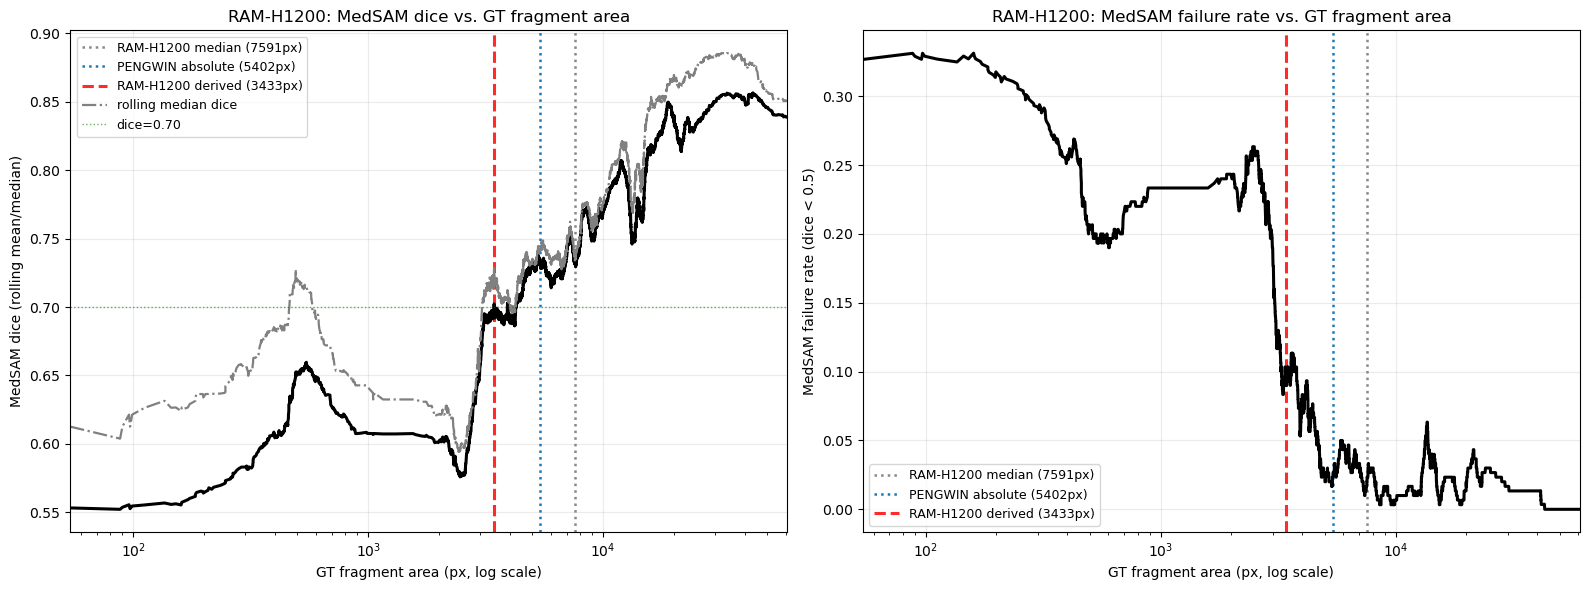

saved -> /Users/ioana/Desktop/FOMO/MoE-ShapeRefine-MedicalSeg/figures/ramh1200_threshold_analysis


In [6]:
# Pick the final derived threshold: the "mean_dice_above_0.70" candidate is the
# one PENGWIN's own actual 5402px value sits closest to (see the notebook intro),
# so use the same criterion here for a methodologically matched comparison.
derived_row = candidates[candidates["criterion"] == "mean_dice_above_0.70"]
DERIVED_THRESHOLD = float(derived_row["area_cutoff"].iloc[0]) if not derived_row.empty and not np.isnan(derived_row["area_cutoff"].iloc[0]) else None
print(f"RAM-H1200 derived threshold (mean dice crosses 0.70): {DERIVED_THRESHOLD}")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, ycol, ylabel, title in [
    (axes[0], "rolling_mean_dice", "MedSAM dice (rolling mean/median)", "RAM-H1200: MedSAM dice vs. GT fragment area"),
    (axes[1], "rolling_failure_rate", f"MedSAM failure rate (dice < {FAILURE_DICE_THRESHOLD})", "RAM-H1200: MedSAM failure rate vs. GT fragment area"),
]:
    x_min, x_max = float(rolling["area"].min()), float(rolling["area"].max())

    for thr, color, lbl in [
        (RAM_H1200_MEDIAN_THRESHOLD, "#888888", f"RAM-H1200 median ({RAM_H1200_MEDIAN_THRESHOLD:.0f}px)"),
        (PENGWIN_ABSOLUTE_THRESHOLD, "#1f77b4", f"PENGWIN absolute ({PENGWIN_ABSOLUTE_THRESHOLD:.0f}px)"),
    ]:
        ax.axvline(thr, color=color, linestyle=":", linewidth=1.8, label=lbl)

    if DERIVED_THRESHOLD is not None:
        ax.axvline(DERIVED_THRESHOLD, color="#FF2B2B", linestyle="--", linewidth=2.2,
                   label=f"RAM-H1200 derived ({DERIVED_THRESHOLD:.0f}px)")

    ax.plot(rolling["area"], rolling[ycol], linewidth=2.2, color="black")
    if ycol == "rolling_mean_dice":
        ax.plot(rolling["area"], rolling["rolling_median_dice"], linewidth=1.6, color="gray", linestyle="-.", label="rolling median dice")
        ax.axhline(0.70, color="green", linestyle=":", linewidth=1, alpha=0.6, label="dice=0.70")

    ax.set_xscale("log")
    ax.set_xlim(x_min, x_max)
    ax.set_xlabel("GT fragment area (px, log scale)")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.grid(True, alpha=0.25)
    ax.legend(fontsize=9, loc="best")

plt.tight_layout()

FIGURES_DIR = REPO_ROOT / "figures" / "ramh1200_threshold_analysis"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
plt.savefig(FIGURES_DIR / f"{SPLIT}_rolling_dice_and_failure_rate_vs_area.png", dpi=200, bbox_inches="tight")
plt.show()
print(f"saved -> {FIGURES_DIR}")


## 7. Summary

Three thresholds, side by side, and what each one means:
- **RAM-H1200 median** (~4000-4600px): purely distributional 50/50 split, no
  reference to segmentation quality. What's been used so far.
- **PENGWIN absolute** (5402px): PENGWIN's own quality-cliff threshold,
  applied here only as an *absolute-scale* reference point (Section 11 of
  the FlowSDF notebook / `--pengwin-reroute` in the script) -- not derived
  from RAM-H1200's own data at all.
- **RAM-H1200 derived** (this notebook): RAM-H1200's *own* quality-cliff
  threshold, using PENGWIN's exact methodology but RAM-H1200's own MedSAM
  failure data. This is the one that would be directly comparable to
  PENGWIN's 5402px in *how* it was derived, even though the resulting pixel
  value will naturally differ by domain.

If the derived threshold sits close to the current median, the simple median
heuristic was fine all along. If it sits meaningfully higher or lower, that's
worth switching to for `compute_gating()` -- print the delta below.

In [7]:
print(f"RAM-H1200 median threshold:   {RAM_H1200_MEDIAN_THRESHOLD:.1f}px")
print(f"PENGWIN absolute threshold:    {PENGWIN_ABSOLUTE_THRESHOLD:.1f}px")
if DERIVED_THRESHOLD is not None:
    print(f"RAM-H1200 derived threshold:   {DERIVED_THRESHOLD:.1f}px")
    print(f"derived vs median delta:       {DERIVED_THRESHOLD - RAM_H1200_MEDIAN_THRESHOLD:+.1f}px "
          f"({(DERIVED_THRESHOLD / RAM_H1200_MEDIAN_THRESHOLD - 1) * 100:+.1f}%)")
else:
    print("No area crossed mean_dice=0.70 in this data -- see the candidates table in Section 4 "
          "for other criteria (failure_rate thresholds etc.) instead.")


RAM-H1200 median threshold:   7591.0px
PENGWIN absolute threshold:    5402.0px
RAM-H1200 derived threshold:   3433.0px
derived vs median delta:       -4158.0px (-54.8%)
